In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

Saving agriculture_ml_dataset_cw.csv to agriculture_ml_dataset_cw.csv


In [2]:
df.columns = df.columns.str.strip()
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation', 'Fertilizer', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen', 'Yield']


In [3]:
print("Shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))

Shape: (2020, 11)

First 10 rows:
   Crop_Type Soil_Type Region  Season Irrigation Fertilizer  Rainfall  \
0      Wheat     Silty  South  Kharif  Sprinkler   Chemical      93.7   
1     Cotton       NaN   West    Zaid      Flood    Organic     146.9   
2     Cotton      Clay  North  Kharif       Drip   Chemical     108.7   
3      Maize      Clay  South  Kharif  Sprinkler   Chemical      72.3   
4      Maize     Silty   West  Kharif      Flood    Organic     119.9   
5  Sugarcane     Loamy   West    Rabi      Flood      Mixed     176.4   
6      Wheat      Clay  South    Rabi  Sprinkler   Chemical     146.1   
7     Cotton     Loamy   East    Zaid        NaN    Organic     200.6   
8       Rice     Silty  North    Rabi       Drip      Mixed     136.2   
9      Wheat     Sandy  North    Rabi  Sprinkler    Organic     215.7   

   Temperature  Humidity  Nitrogen  Yield  
0         22.9      69.0     115.0   5.13  
1         25.6       NaN      71.0   5.40  
2         22.1       NaN      

In [4]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop_Type    2020 non-null   object 
 1   Soil_Type    1899 non-null   object 
 2   Region       2020 non-null   object 
 3   Season       2020 non-null   object 
 4   Irrigation   1900 non-null   object 
 5   Fertilizer   2020 non-null   object 
 6   Rainfall     1899 non-null   float64
 7   Temperature  1900 non-null   float64
 8   Humidity     1898 non-null   float64
 9   Nitrogen     1899 non-null   float64
 10  Yield        2020 non-null   float64
dtypes: float64(5), object(6)
memory usage: 173.7+ KB
None

Missing values:
Crop_Type        0
Soil_Type      121
Region           0
Season           0
Irrigation     120
Fertilizer       0
Rainfall       121
Temperature    120
Humidity       122
Nitrogen       121
Yield            0
dtype: int64


In [5]:
print(df.describe())

num_cols = df.select_dtypes(include=['int64','float64']).columns

print("\nHighest mean feature:")
print(df[num_cols].mean().idxmax())

print("\nHighest std feature:")
print(df[num_cols].std().idxmax())

          Rainfall  Temperature     Humidity     Nitrogen        Yield
count  1899.000000  1900.000000  1898.000000  1899.000000  2020.000000
mean    129.723960    26.875421    67.740622    79.169036     5.442926
std      35.395931     4.104174    12.046501    22.876734     1.062772
min      22.800000    12.900000    30.600000    40.000000     1.740000
25%     107.100000    24.200000    59.500000    59.000000     4.700000
50%     128.100000    26.900000    67.650000    79.000000     5.430000
75%     153.500000    29.600000    75.800000    99.000000     6.172500
max     245.300000    43.100000   117.800000   119.000000     8.910000

Highest mean feature:
Rainfall

Highest std feature:
Rainfall


In [6]:
print("Numeric columns:", num_cols)

cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", cat_cols)

Numeric columns: Index(['Rainfall', 'Temperature', 'Humidity', 'Nitrogen', 'Yield'], dtype='object')
Categorical columns: Index(['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation',
       'Fertilizer'],
      dtype='object')


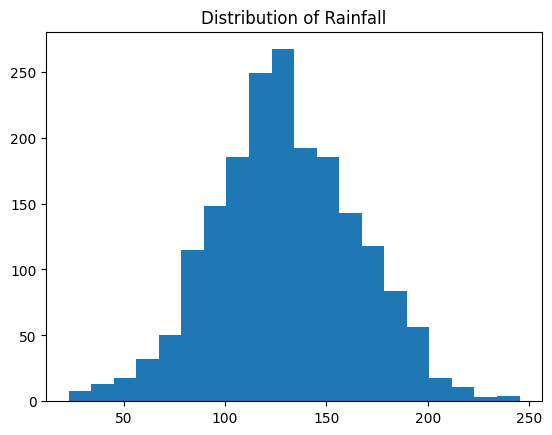

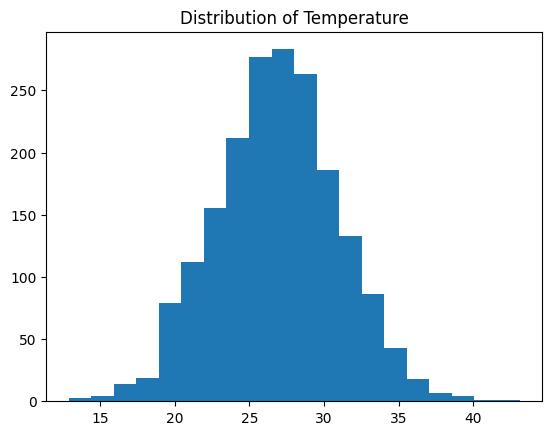

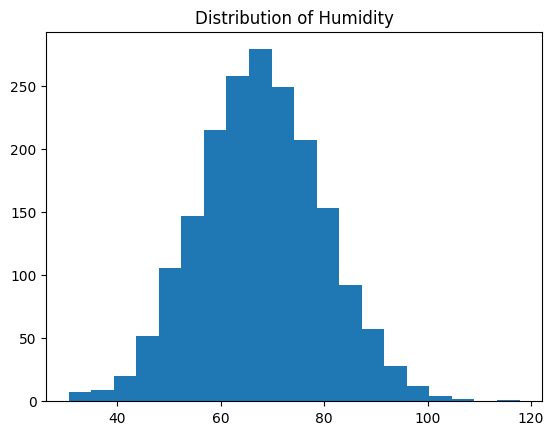

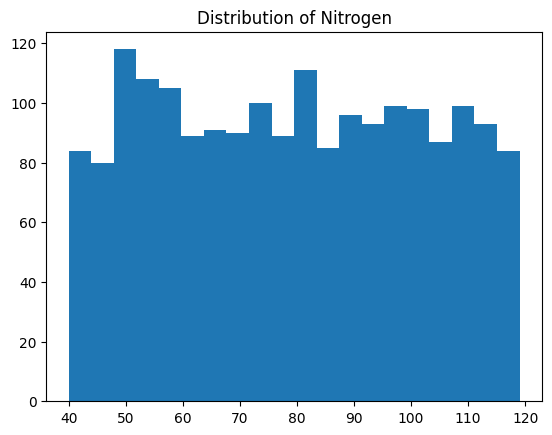

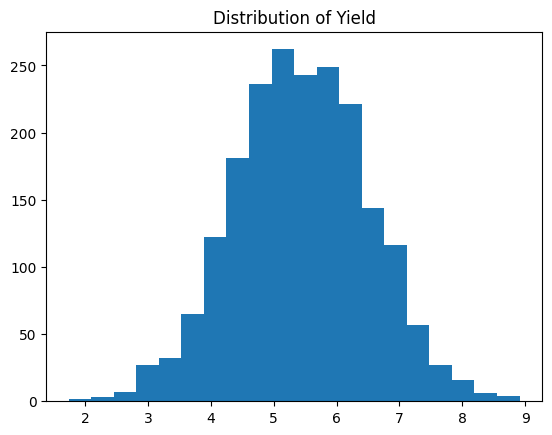

In [7]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()


 Crop_Type value counts:
Crop_Type
Maize        426
Wheat        422
Sugarcane    403
Cotton       399
Rice         370
Name: count, dtype: int64


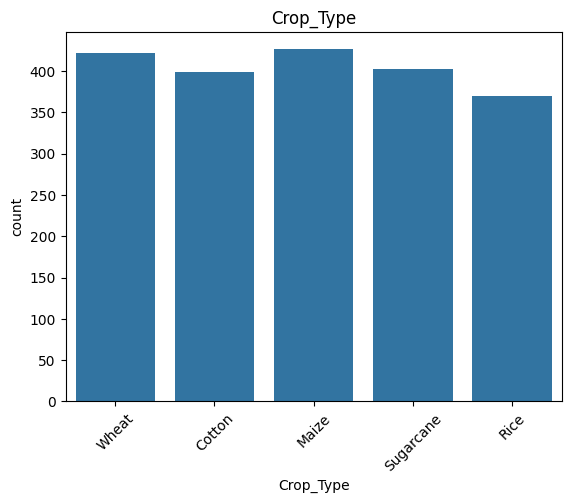


 Soil_Type value counts:
Soil_Type
Silty    493
Loamy    482
Clay     463
Sandy    461
Name: count, dtype: int64


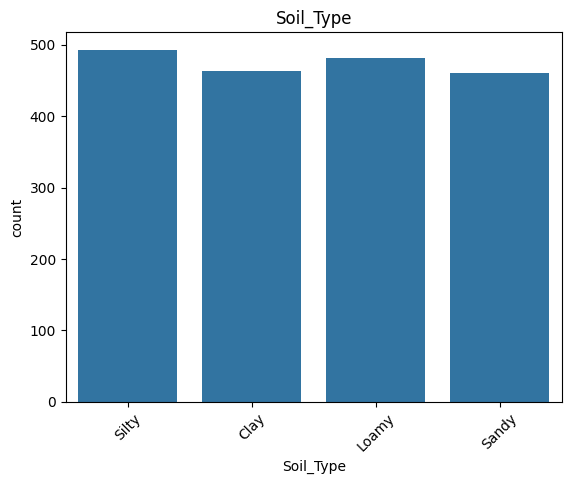


 Region value counts:
Region
South    522
West     502
North    502
East     494
Name: count, dtype: int64


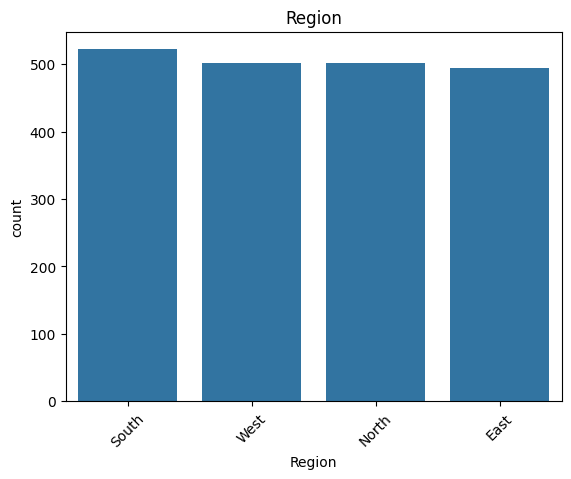


 Season value counts:
Season
Rabi      727
Kharif    661
Zaid      632
Name: count, dtype: int64


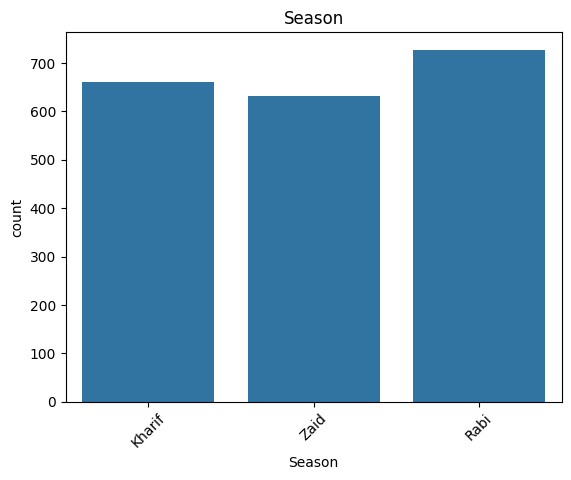


 Irrigation value counts:
Irrigation
Sprinkler    654
Drip         624
Flood        622
Name: count, dtype: int64


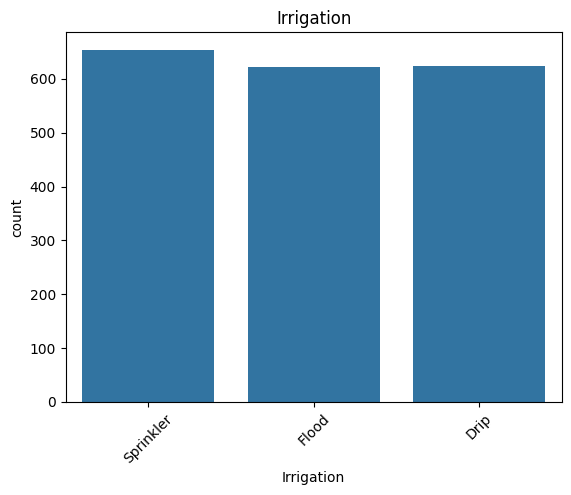


 Fertilizer value counts:
Fertilizer
Chemical    687
Organic     669
Mixed       664
Name: count, dtype: int64


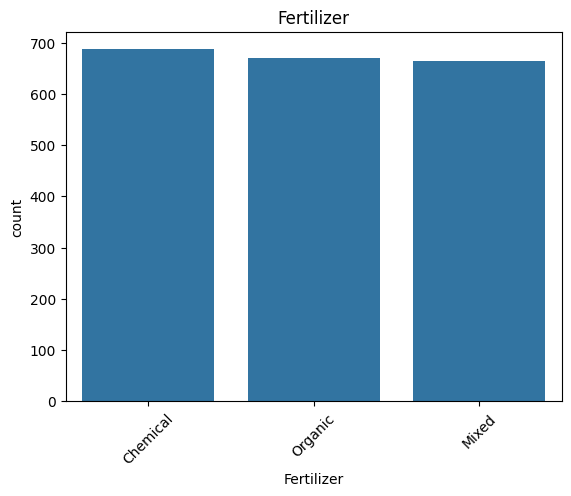

In [8]:
import seaborn as sns

for col in cat_cols:
    print("\n", col, "value counts:")
    print(df[col].value_counts())

    plt.figure()
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

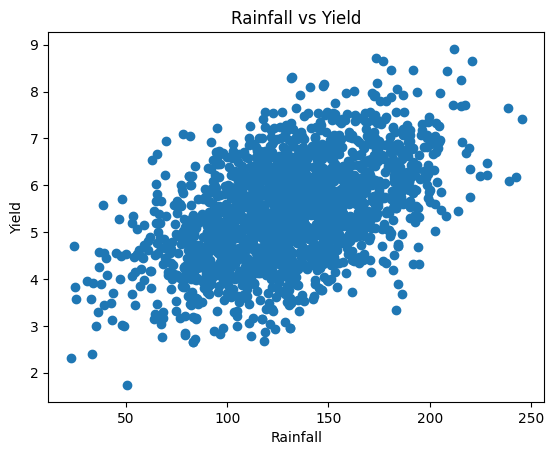

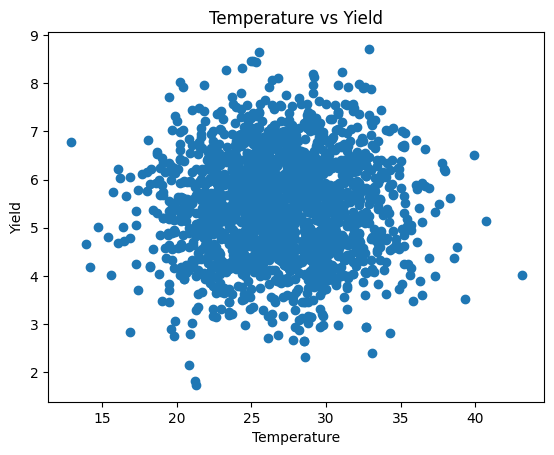

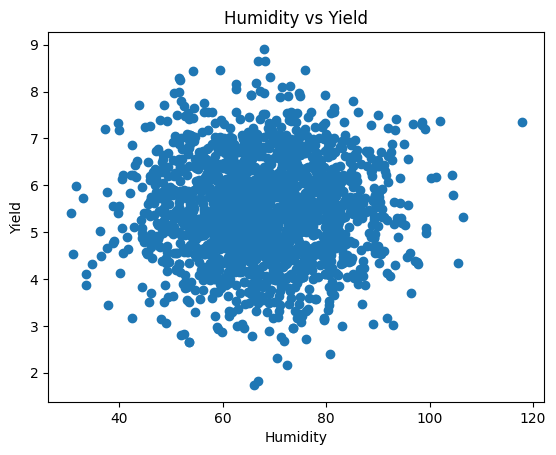

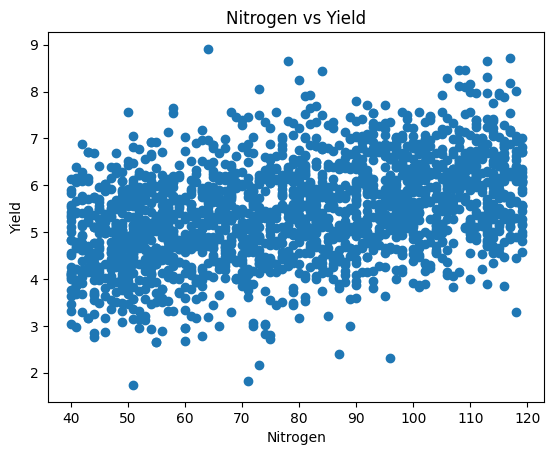

In [9]:
target = num_cols[-1]  # assume last numeric column is yield

for col in num_cols[:-1]:
    plt.figure()
    plt.scatter(df[col], df[target])
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target}")
    plt.show()

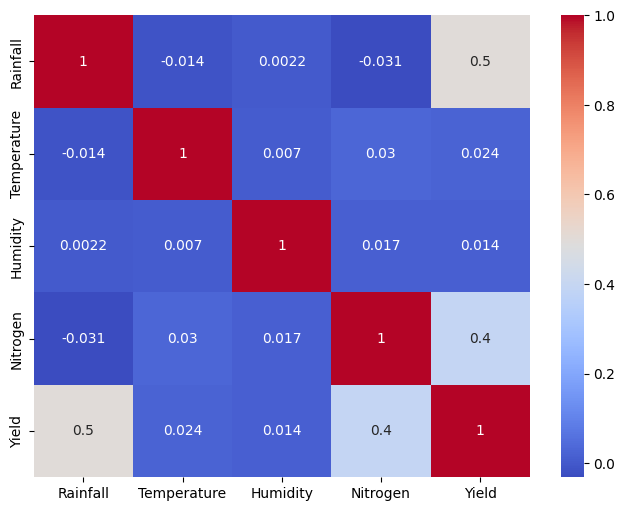


Top correlated features with target:
Yield          1.000000
Rainfall       0.498788
Nitrogen       0.395801
Temperature    0.023503
Humidity       0.013557
Name: Yield, dtype: float64


In [10]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

print("\nTop correlated features with target:")
print(corr[target].sort_values(ascending=False))

In [11]:
for col in cat_cols:
    print("\nAverage target by", col)
    print(df.groupby(col)[target].mean())


Average target by Crop_Type
Crop_Type
Cotton       5.434286
Maize        5.439014
Rice         5.368919
Sugarcane    5.445434
Wheat        5.517536
Name: Yield, dtype: float64

Average target by Soil_Type
Soil_Type
Clay     5.509352
Loamy    5.347427
Sandy    5.452777
Silty    5.439919
Name: Yield, dtype: float64

Average target by Region
Region
East     5.398381
North    5.467112
South    5.488755
West     5.414920
Name: Yield, dtype: float64

Average target by Season
Season
Kharif    5.453253
Rabi      5.503095
Zaid      5.362911
Name: Yield, dtype: float64

Average target by Irrigation
Irrigation
Drip         5.475561
Flood        5.440514
Sprinkler    5.418930
Name: Yield, dtype: float64

Average target by Fertilizer
Fertilizer
Chemical    5.449418
Mixed       5.445572
Organic     5.433632
Name: Yield, dtype: float64


In [12]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())

   Rainfall  Temperature  Humidity  Nitrogen  Yield  Crop_Type_Maize  \
0      93.7         22.9      69.0     115.0   5.13            False   
1     146.9         25.6       NaN      71.0   5.40            False   
2     108.7         22.1       NaN      86.0   4.26            False   
3      72.3         26.8      69.4      44.0   4.35             True   
4     119.9         26.3      44.3      48.0   4.88             True   

   Crop_Type_Rice  Crop_Type_Sugarcane  Crop_Type_Wheat  Soil_Type_Loamy  ...  \
0           False                False             True            False  ...   
1           False                False            False            False  ...   
2           False                False            False            False  ...   
3           False                False            False            False  ...   
4           False                False            False            False  ...   

   Soil_Type_Silty  Region_North  Region_South  Region_West  Season_Rabi  \
0   

In [13]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1616, 20) (404, 20) (1616,) (404,)


In [15]:
from sklearn.linear_model import LinearRegression

# STEP 1: Remove missing values (VERY IMPORTANT)
df_encoded = df_encoded.dropna()

In [16]:
# STEP 2: Ensure only numeric data
df_encoded = df_encoded.select_dtypes(include=['int64','float64','uint8','bool'])

In [17]:
# STEP 3: Re-define X and y safely
target = df_encoded.columns[-1]   # last column assumed as yield

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

In [18]:
# STEP 4: Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# STEP 5: Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
# STEP 6: Predictions
y_pred = model.predict(X_test)

In [21]:
# STEP 7: Coefficients
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef_df.sort_values(by="Coefficient", ascending=False))

                 Feature  Coefficient
12          Region_North     0.127872
14           Region_West     0.069336
11       Soil_Type_Silty     0.045902
13          Region_South     0.034779
5        Crop_Type_Maize     0.025597
4                  Yield     0.017197
9        Soil_Type_Loamy     0.013338
0               Rainfall    -0.000418
2               Humidity    -0.000558
3               Nitrogen    -0.000687
10       Soil_Type_Sandy    -0.000955
1            Temperature    -0.004054
6         Crop_Type_Rice    -0.004372
17      Irrigation_Flood    -0.006237
18  Irrigation_Sprinkler    -0.009966
7    Crop_Type_Sugarcane    -0.019144
16           Season_Zaid    -0.020281
15           Season_Rabi    -0.020527
8        Crop_Type_Wheat    -0.021622
19      Fertilizer_Mixed    -0.487658


In [22]:
# STEP 8: Intercept
print("Intercept:", model.intercept_)

Intercept: 0.6017411125951093


In [23]:
# STEP 9: Best feature
print("Most important feature:")
print(coef_df.loc[coef_df["Coefficient"].idxmax()])


Most important feature:
Feature        Region_North
Coefficient        0.127872
Name: 12, dtype: object
